ProtoNet = learns embeddings → calculates the prototype (mean vector) for each class

Prediction = selects the class with the closest distance

Training in episodes (N-way, K-shot)

👉 Main idea:

Support set → create prototype

Query → compare with prototype → classify

ProtoNet works by learning the embedding space and classifying based on the distance to the “prototype” (mean vector) of each class

In [1]:
!pip install torch torchvision tqdm

In [2]:
import torch
from torchvision.datasets import Omniglot
from torchvision import transforms

transform = transforms.Compose([
    transforms.Resize((28, 28)),
    transforms.ToTensor()
])

train_dataset = Omniglot(
    root="./data",
    background=True,
    download=True,
    transform=transform
)

test_dataset = Omniglot(
    root="./data",
    background=False,
    download=True,
    transform=transform
)

100%|██████████| 9.46M/9.46M [00:00<00:00, 386MB/s]
100%|██████████| 6.46M/6.46M [00:00<00:00, 404MB/s]


In [3]:
import random
from collections import defaultdict

def create_episode(dataset, n_way=5, k_shot=5, q_query=15):
    data_by_class = defaultdict(list)

    for img, label in dataset:
        data_by_class[label].append(img)

    selected_classes = random.sample(list(data_by_class.keys()), n_way)

    support_x, support_y = [], []
    query_x, query_y = [], []

    for i, cls in enumerate(selected_classes):
        samples = random.sample(data_by_class[cls], k_shot + q_query)

        support_x += samples[:k_shot]
        query_x += samples[k_shot:]

        support_y += [i] * k_shot
        query_y += [i] * q_query

    return (
        torch.stack(support_x),
        torch.tensor(support_y),
        torch.stack(query_x),
        torch.tensor(query_y)
    )

In [4]:
import torch.nn as nn
import torch.nn.functional as F

class ProtoNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Conv2d(1, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

    def forward(self, x):
        x = self.encoder(x)
        return x.view(x.size(0), -1)

In [5]:
def euclidean_dist(a, b):
    n = a.size(0)
    m = b.size(0)
    a = a.unsqueeze(1).expand(n, m, -1)
    b = b.unsqueeze(0).expand(n, m, -1)
    return torch.pow(a - b, 2).sum(2)

In [6]:
def prototypical_loss(support_x, support_y, query_x, query_y, model):
    support_emb = model(support_x)
    query_emb = model(query_x)

    classes = torch.unique(support_y)

    prototypes = []
    for c in classes:
        prototypes.append(support_emb[support_y == c].mean(0))
    prototypes = torch.stack(prototypes)

    dists = euclidean_dist(query_emb, prototypes)
    log_p_y = F.log_softmax(-dists, dim=1)

    loss = -log_p_y.gather(1, query_y.unsqueeze(1)).mean()

    pred = log_p_y.argmax(dim=1)
    acc = (pred == query_y).float().mean()

    return loss, acc

In [7]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = ProtoNet().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

for episode in range(1000):
    support_x, support_y, query_x, query_y = create_episode(train_dataset)

    support_x, support_y = support_x.to(device), support_y.to(device)
    query_x, query_y = query_x.to(device), query_y.to(device)

    loss, acc = prototypical_loss(support_x, support_y, query_x, query_y, model)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if episode % 50 == 0:
        print(f"Episode {episode} | Loss: {loss.item():.4f} | Acc: {acc.item():.4f}")

Episode 0 | Loss: 0.2607 | Acc: 0.9333
Episode 50 | Loss: 0.1874 | Acc: 0.9600
Episode 100 | Loss: 0.1653 | Acc: 0.9333
Episode 150 | Loss: 0.1622 | Acc: 0.9467
Episode 200 | Loss: 0.0039 | Acc: 1.0000
Episode 250 | Loss: 0.0092 | Acc: 1.0000
Episode 300 | Loss: 0.0924 | Acc: 0.9733
Episode 350 | Loss: 0.0036 | Acc: 1.0000
Episode 400 | Loss: 0.0041 | Acc: 1.0000
Episode 450 | Loss: 0.1328 | Acc: 0.9867
Episode 500 | Loss: 0.0226 | Acc: 0.9867
Episode 550 | Loss: 0.0375 | Acc: 0.9867
Episode 600 | Loss: 0.0634 | Acc: 0.9600
Episode 650 | Loss: 0.1064 | Acc: 0.9600
Episode 700 | Loss: 0.0602 | Acc: 0.9867
Episode 750 | Loss: 0.0056 | Acc: 1.0000
Episode 800 | Loss: 0.0013 | Acc: 1.0000
Episode 850 | Loss: 0.0223 | Acc: 0.9867
Episode 900 | Loss: 0.1310 | Acc: 0.9333
Episode 950 | Loss: 0.3131 | Acc: 0.9733


In [8]:
model.eval()

with torch.no_grad():
    accs = []

    for _ in range(100):
        support_x, support_y, query_x, query_y = create_episode(test_dataset)

        support_x, support_y = support_x.to(device), support_y.to(device)
        query_x, query_y = query_x.to(device), query_y.to(device)

        _, acc = prototypical_loss(support_x, support_y, query_x, query_y, model)
        accs.append(acc.item())

    print("Test Accuracy:", sum(accs)/len(accs))

Test Accuracy: 0.9746666818857193


In [11]:
def predict_one(model, dataset, n_way=5, k_shot=5):
    model.eval()

    support_x, support_y, query_x, query_y = create_episode(
        dataset, n_way=n_way, k_shot=k_shot, q_query=1
    )

    support_x = support_x.to(device)
    query_x = query_x.to(device)

    with torch.no_grad():
        support_emb = model(support_x)
        query_emb = model(query_x)

        classes = torch.unique(support_y)
        prototypes = torch.stack([
            support_emb[support_y == c].mean(0)
            for c in classes
        ])

        dists = euclidean_dist(query_emb, prototypes)
        pred = torch.argmin(dists, dim=1)

    print("Predicted:", pred[0].item())
    print("Ground truth:", query_y[0].item())

In [12]:
predict_one(model, test_dataset)

Predicted: 0
Ground truth: 0


In [13]:
import matplotlib.pyplot as plt

def visualize_episode(dataset, n_way=5, k_shot=5):
    support_x, support_y, query_x, query_y = create_episode(
        dataset, n_way=n_way, k_shot=k_shot, q_query=1
    )

    fig, axes = plt.subplots(n_way, k_shot + 1, figsize=(10, 10))

    for i in range(n_way):
        for j in range(k_shot):
            axes[i, j].imshow(support_x[i*k_shot+j].squeeze(), cmap='gray')
            axes[i, j].set_title(f"S{i}")
            axes[i, j].axis('off')

        axes[i, k_shot].imshow(query_x[i].squeeze(), cmap='gray')
        axes[i, k_shot].set_title(f"Q{i}")
        axes[i, k_shot].axis('off')

    plt.show()

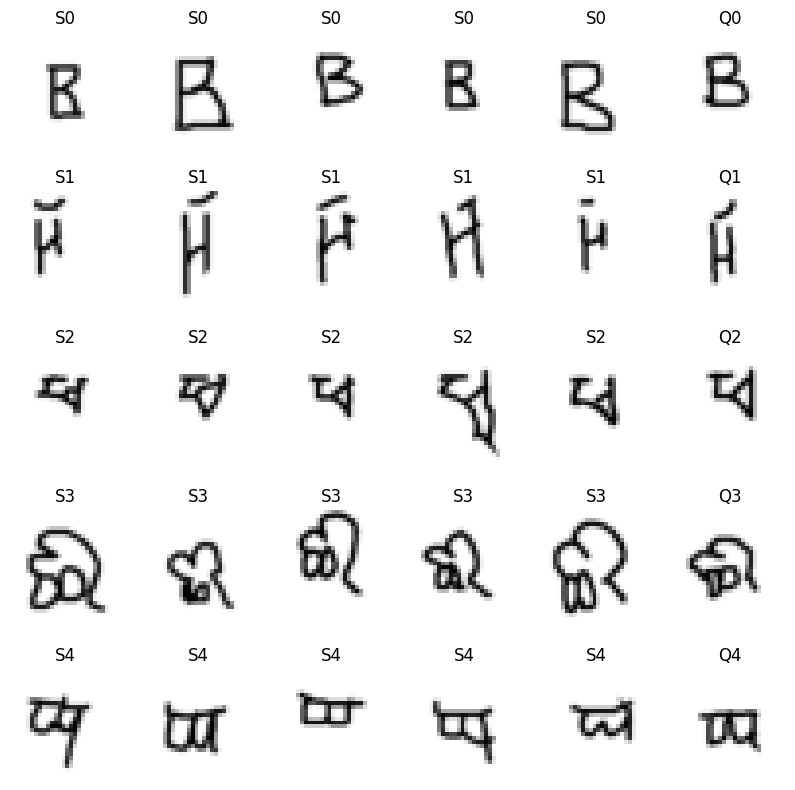

In [14]:
visualize_episode(test_dataset)